#Transfer learning with EfficientNetV2B0

## Import libraries and mount drive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Rescaling, Input, Resizing, GlobalAveragePooling2D, Dropout, Flatten, Dense,BatchNormalization, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomContrast
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.optimizers import Adam

In [13]:
import os
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/CNN_project'
os.chdir(project_path)
# Create folder structure
os.makedirs(f'{project_path}/Jupyter_Notebooks', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn1', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn2', exist_ok=True)
os.makedirs(f'{project_path}/models', exist_ok=True)
os.makedirs(f'{project_path}/metrics', exist_ok=True)

Mounted at /content/drive


In [10]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

loss="sparse_categorical_crossentropy" #we can keep labels as integers

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("First label value:", y_train[0][0])
print("First label name:", class_names[y_train[0][0]])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 184s 1us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
First label value: 6
First label name: frog


## Dataset inspection

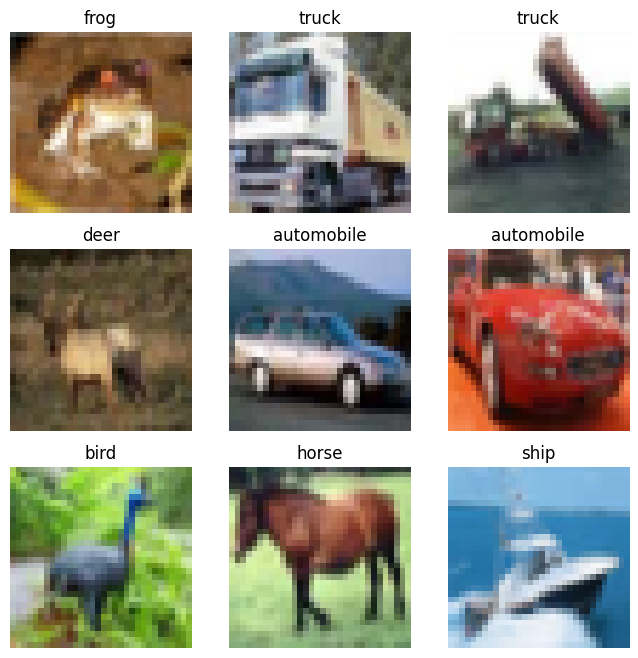

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

## Functions

### Callbacks

In [17]:
def create_callbacks(model_name, project_path, min_lr, patience, patience_lr, factor):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        filepath=f"{project_path}/models/N_{model_name}.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min"
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=factor,
        patience=patience_lr,
        min_lr= min_lr,
        verbose = 1
    )

    return [early_stop, checkpoint, reduce_lr]

### loss and accuracy curves

In [18]:
def acc_loss_viz(history, model_name):
    plt.figure(figsize=(12, 6))

    history_df = pd.DataFrame(history.history)

    acc = history_df["accuracy"]
    val_acc = history_df["val_accuracy"]
    loss = history_df["loss"]
    val_loss = history_df["val_loss"]

    max_val_acc = max(val_acc)
    epoch_max_acc = np.argmax(val_acc)

    min_val_loss = min(val_loss)
    epoch_min_loss = np.argmin(val_loss)

    plt.subplot(1, 2, 1)
    plt.plot(acc, label="Train")
    plt.plot(val_acc, label="Validation", color="orange")
    plt.axhline(y=max_val_acc, color="red", linestyle="--", alpha=0.5)
    plt.axvline(x=epoch_max_acc, color="green", linestyle=":", alpha=0.8)
    plt.text(epoch_max_acc, max_val_acc, f" Acc: {max_val_acc:.4f}", color="red", fontweight="bold")
    plt.text(epoch_max_acc, plt.ylim()[0], f" Epoch: {epoch_max_acc}", color="green", fontweight="bold", ha="left", va="bottom")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="Train")
    plt.plot(val_loss, label="Validation", color="orange")
    plt.axhline(y=min_val_loss, color="blue", linestyle="--", alpha=0.5)
    plt.axvline(x=epoch_min_loss, color="green", linestyle=":", alpha=0.8)
    plt.text(epoch_min_loss, min_val_loss, f" Loss: {min_val_loss:.4f}", color="blue", fontweight="bold")
    plt.text(epoch_min_loss, plt.ylim()[0], f" Epoch: {epoch_min_loss}", color="green", fontweight="bold", ha="left", va="bottom")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    plt.suptitle(model_name, fontsize=12)
    plt.tight_layout()
    plt.show()

def combine_histories(history_1, history_2, keys=("loss", "accuracy", "val_loss", "val_accuracy")):
    combined = {}

    for key in keys:
        if key in history_1.history and key in history_2.history:
            combined[key] = history_1.history[key] + history_2.history[key]

    return type("CombinedHistory", (), {"history": combined})()

### Evaluation (F1, Recall, accuracy)

In [19]:
def evaluate_model(model_name, model, train_data, test_data, y_test):
    # Evaluate on train and test datasets
    train_loss, train_acc = model.evaluate(train_data, verbose=0)
    test_loss, test_acc = model.evaluate(test_data, verbose=0)

    # returns 10 probabilities per image, one per CIFAR-10 class
    y_pred_probs = model.predict(test_data)

    # picks the index of the highest probability for each image
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Flatten true labels from shape (10000, 1) to (10000,)
    y_true = y_test.ravel()

    # Compute extra classification metrics
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    results = pd.DataFrame([{
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Train Loss": train_loss,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }])

    # Return results as one-row dataframe
    return results, y_pred, y_true



### Confusion Matrix

In [20]:
def confuse(y_true, y_pred, class_names=class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(title)
    plt.show()

    return cm

## preprocessing for EfficientNetV2B0

First, we need to resize from 32×32 to a larger input size. We’ll use 224×224, because that matches common ImageNet transfer learning settings. Then, We shuffle training data so the model does not learn patterns from the order of examples. We do not shuffle test data because evaluation does not update weights, and keeping the order stable makes predictions, confusion matrices, and error inspection easier.

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
VAL_SIZE = 10000 #size of the validation dataset

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=y_train
)

# Converts NumPy arrays into a TensorFlow Dataset. Each item becomes one pair (image, label)
train_ds = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(len(X_train_final)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## Load EfficientNetV2B0

In [10]:
model_name="EfficientNetV2B0_baseline"
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## build the model on top of the pretrained mode

In [ ]:
inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)

# Pass resized images through the frozen pretrained EfficientNetV2B0 base
# training=False keeps BatchNorm layers in inference mode
x = base_model(x, training=False)

# Convert the feature maps into a single feature vector
#x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = Flatten()(x)

#x = tf.keras.layers.Dropout(0.3)(x)

outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       627,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,546,522 (24.97 MB)

 Trainable params: 627,210 (2.39 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

##Train the model

In [ ]:
lr = 1e-3
epochs = 10
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_baseline = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.8562 - loss: 1.3712 - val_accuracy: 0.8809 - val_loss: 1.5365
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9329 - loss: 0.6758 - val_accuracy: 0.8979 - val_loss: 1.4146
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9529 - loss: 0.4818 - val_accuracy: 0.9034 - val_loss: 1.5789
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9621 - loss: 0.3794 - val_accuracy: 0.9086 - val_loss: 1.6351
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9674 - loss: 0.3505 - val_accuracy: 0.9078 - val_loss: 1.8169
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9699 - loss: 0.3486 - val_accuracy: 0.9127 - val_loss: 1.9648
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9733 - loss: 0.3235 - val_accuracy: 0.9156 - val_loss: 1.9064
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9743 - loss: 0.3362 - 

In [ ]:
baseline_results, y_pred, y_true = evaluate_model(
    model_name,
    model=model,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

baseline_results

157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step


,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.99375,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024


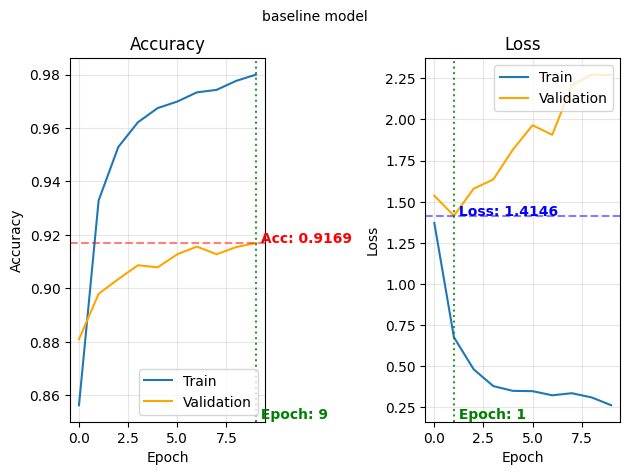

In [ ]:
acc_loss_viz(history_baseline, 'baseline model')

In [ ]:
model.save(f'{project_path}/models/N_{model_name}.keras')
metrics_TL = baseline_results.copy()
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.99375,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024


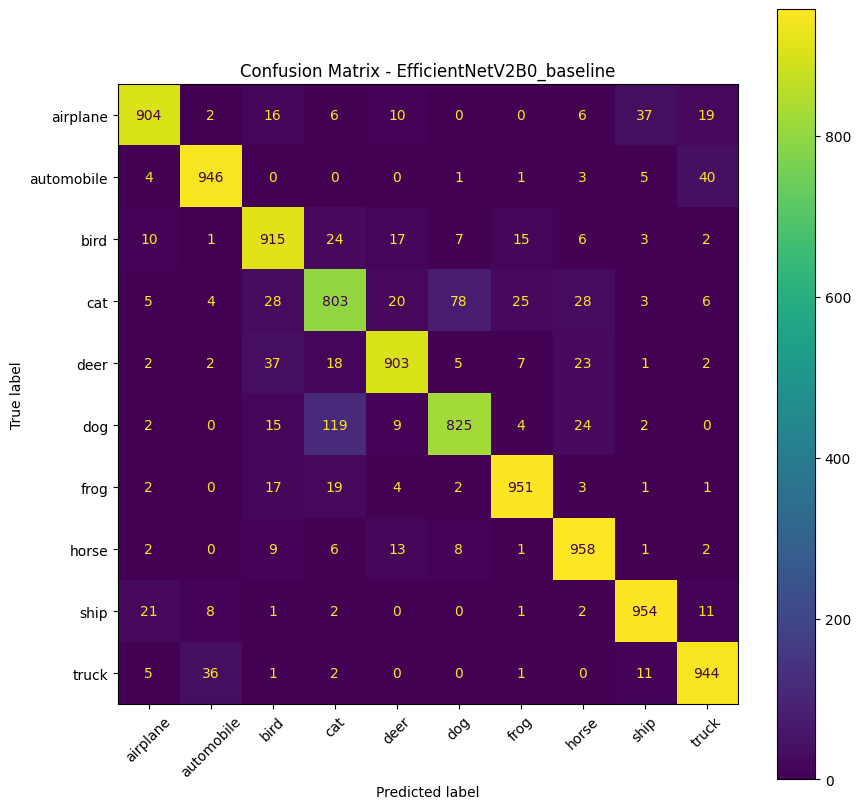

In [ ]:
cm_base = confuse(y_true, y_pred, title=f"Confusion Matrix - {model_name}")

The model achieves strong test accuracy, but the very high test loss suggests it makes some wrong predictions with high confidence. The gap between train accuracy and test accuracy, together with rising validation loss while training loss decreases, indicates overfitting. This is likely caused by using Flatten(), which creates a large classification head with many parameters.

## Test 1: Global Average pooling

The global Average pooling summarizes each feature map into one value and should reduce the number of parameters, improving generalization.

In [ ]:
model_name="EfficientNetV2B0_GAP"

inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) #TEST 1: Global Average Pooling
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_gap = Model(inputs, outputs)

model_gap.summary()

lr = 1e-3
epochs = 10
model_gap.compile(
    optimizer=Adam(learning_rate=lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_gap = model_gap.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

gap_results, y_pred, y_true = evaluate_model(
    model_name,
    model=model_gap,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

gap_results

model_gap.save(f'{project_path}/models/N_{model_name}.keras')
metrics_TL = pd.concat([metrics_TL, gap_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)





Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - accuracy: 0.8494 - loss: 0.4871 - val_accuracy: 0.8993 - val_loss: 0.3024
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8954 - loss: 0.3134 - val_accuracy: 0.9072 - val_loss: 0.2713
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9050 - loss: 0.2806 - val_accuracy: 0.9129 - val_loss: 0.2577
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9109 - loss: 0.2639 - val_accuracy: 0.9135 - val_loss: 0.2525
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9146 - loss: 0.2523 - val_accuracy: 0.9144 - val_loss: 0.2494
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9175 - loss: 0.2401 - val_accuracy: 0.9169 - val_loss: 0.2436
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9204 - loss: 0.2346 - val_accuracy: 0.9159 - val_loss: 0.2423
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9215 - loss: 0.2293 - 

Replacing Flatten() with GlobalAveragePooling2D() reduced the trainable parameters from 627,210 to 12,810. This makes the classification head much simpler and reduces overfitting risk. Training accuracy may decrease slightly, because the model has less capacity to memorize the training data, but validation and test loss should improve because the model should generalize better to unseen images.

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126


 Although training accuracy decreased from 99.2% to 94.5%, test accuracy slightly improved from 91.15% to 91.58%, while test loss drastically decreased from 2.56 to 0.24. This indicates that the Flatten() head was overfitting the training data and producing overly confident predictions on unseen images. GlobalAveragePooling2D() reduced the trainable parameters from 627,210 to 12,810, creating a much simpler classification head that generalized better to the CIFAR-10 test set.

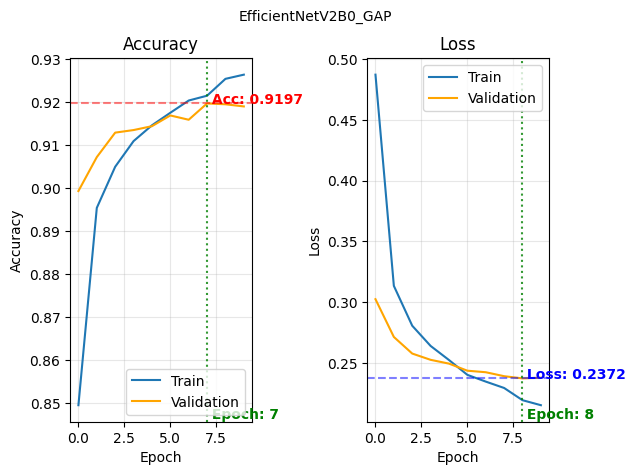

In [ ]:
acc_loss_viz(history_gap, "EfficientNetV2B0_GAP")

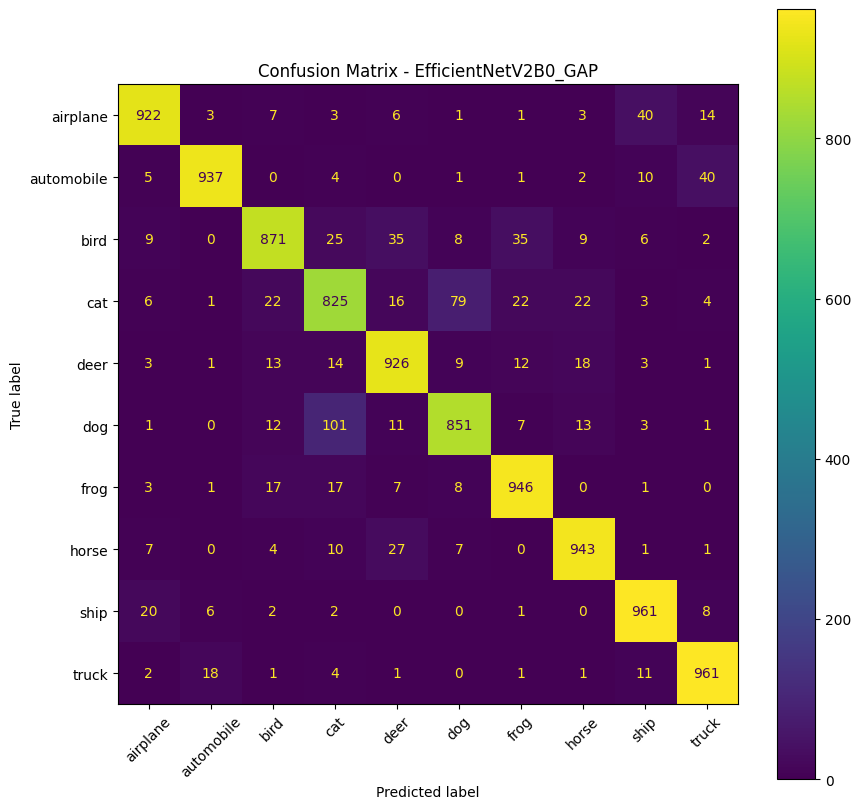

In [ ]:
cm_gap = confuse(y_true, y_pred, title=f"Confusion Matrix - {model_name}")

## Test 2: Dropout

Adding Dropout(0.3) after GlobalAveragePooling2D may improve generalization by making the classification head less dependent on specific features. However, since the GAP model already has few trainable parameters and shows limited overfitting, dropout may only produce a small improvement or even slightly reduce accuracy if it regularizes too aggressively. Dropout randomly disables 30% of the pooled feature activations during each training step, forcing the classification head to avoid relying too strongly on specific features.

In [ ]:
model_name="EfficientNetV2B0_Dropout"

inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) #TEST 1: Global Average Pooling
x = Dropout(0.3)(x)             #TEST 2: Dropout
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_dropout = Model(inputs, outputs)

model_dropout.summary()

lr = 1e-3
epochs = 10
model_dropout.compile(
    optimizer=Adam(learning_rate=lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dropout = model_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

dropout_results, y_pred, y_true = evaluate_model(
    model_name,
    model=model_dropout,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_dropout.save(f'{project_path}/models/N_{model_name}.keras')
metrics_TL = pd.concat([metrics_TL, dropout_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.8327 - loss: 0.5249 - val_accuracy: 0.8951 - val_loss: 0.3141
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8823 - loss: 0.3500 - val_accuracy: 0.9058 - val_loss: 0.2798
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8912 - loss: 0.3212 - val_accuracy: 0.9087 - val_loss: 0.2677
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8928 - loss: 0.3114 - val_accuracy: 0.9124 - val_loss: 0.2603
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8958 - loss: 0.3024 - val_accuracy: 0.9149 - val_loss: 0.2575
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8985 - loss: 0.2947 - val_accuracy: 0.9154 - val_loss: 0.2526
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8984 - loss: 0.2938 - val_accuracy: 0.9170 - val_loss: 0.2477
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8993 - loss: 0.2876 - 

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639


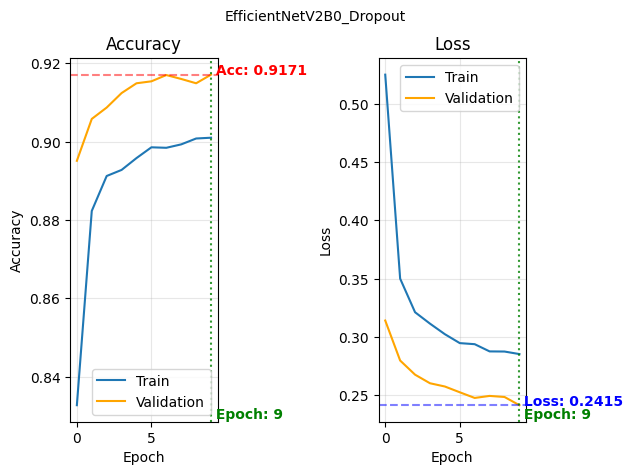

In [ ]:
acc_loss_viz(history_dropout, model_name)

## Test 3: more epochs with early stop and dynamic learning rate

In [ ]:
epochs = 100                     #TEST 3: 100 epochs with dynamic learning rate
min_lr = 1e-6                    #TEST 3: 100 epochs with dynamic learning rate
patience = 10                    #TEST 3: 100 epochs with dynamic learning rate
patience_lr = 3                  #TEST 3: 100 epochs with dynamic learning rate
factor = 0.5                     #TEST 3: 100 epochs with dynamic learning rate

model_name=f"EfficientNetV2B0_E{epochs}P{patience}ML{min_lr}PL{patience_lr}F{factor}"

inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) #TEST 1: Global Average Pooling
x = Dropout(0.3)(x)             #TEST 2: Dropout
outputs = Dense(10, activation="softmax")(x)

model_E100_DLR = Model(inputs, outputs)

model_E100_DLR.summary()

lr = 1e-3
epochs = epochs
model_E100_DLR.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

call_backs = create_callbacks(model_name, project_path, min_lr, patience, patience_lr, factor) #TEST 3: 100 epochs with dynamic learning rate

history_E100_DLR = model_E100_DLR.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=call_backs
)

E100_DLR_results, y_pred, y_true = evaluate_model(
    model_name,
    model=model_E100_DLR,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# model_E100_DLR.save(f'{project_path}/models/N_{model_name}.keras') handled by the checkpoint function inside the create_callbacks
metrics_TL = pd.concat([metrics_TL, E100_DLR_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.8326 - loss: 0.5312 - val_accuracy: 0.8964 - val_loss: 0.3131 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8809 - loss: 0.3478 - val_accuracy: 0.9062 - val_loss: 0.2808 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8905 - loss: 0.3211 - val_accuracy: 0.9108 - val_loss: 0.2673 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8933 - loss: 0.3079 - val_accuracy: 0.9136 - val_loss: 0.2593 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8968 - loss: 0.2999 - val_accuracy: 0.9137 - val_loss: 0.2569 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8985 - loss: 0.2950 - val_accuracy: 0.9138 - val_loss: 0.2517 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287


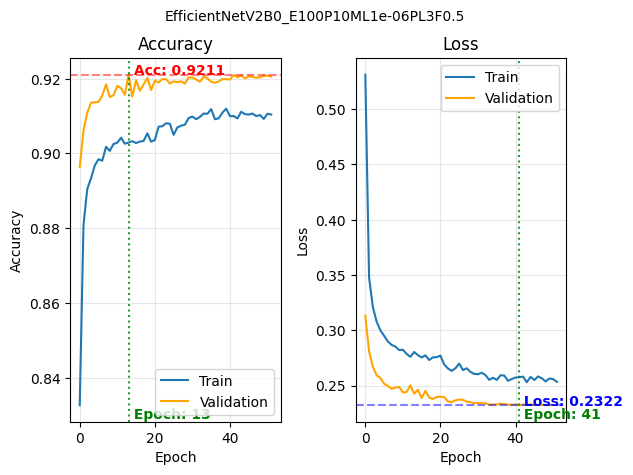

In [ ]:
acc_loss_viz(history_E100_DLR, model_name)

Extending training to 100 epochs with EarlyStopping and ReduceLROnPlateau did not produce a meaningful improvement over the simpler GAP model. Test accuracy remained similar, while test loss improved only marginally. Given the additional training time and compute cost, this experiment suggests that longer training with dropout and dynamic learning rate scheduling does not justify the extra complexity for this frozen feature-extraction setup.

## Test 4: Fine tuning

Unfreezing some top EfficientNetV2B0 layers may allow the pretrained features to adapt slightly to CIFAR-10, potentially improving class separation for difficult categories like cat/dog.

In [ ]:
base_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
len(base_model.layers)
for i, layer in enumerate(base_model.layers[-20:]):
    print(i, layer.name, layer.trainable)

0 block6g_drop False
1 block6g_add False
2 block6h_expand_conv False
3 block6h_expand_bn False
4 block6h_expand_activation False
5 block6h_dwconv2 False
6 block6h_bn False
7 block6h_activation False
8 block6h_se_squeeze False
9 block6h_se_reshape False
10 block6h_se_reduce False
11 block6h_se_expand False
12 block6h_se_excite False
13 block6h_project_conv False
14 block6h_project_bn False
15 block6h_drop False
16 block6h_add False
17 top_conv False
18 top_bn False
19 top_activation False


In the [Tensor Flow Transfer learning & Fine tuning guide](https://www.tensorflow.org/guide/keras/transfer_learning) is specifically stated that:

> *When you unfreeze a model that contains **BatchNormalization layers** in order to do fine-tuning, you should keep the BatchNormalization layers in inference mode by passing training=False when calling the base model. Otherwise the updates applied to the non-trainable weights will suddenly destroy what the model has learned.*

For the first fine-tuning experiment, I unfroze only the final EfficientNetV2B0 sub-block (`block6h`) and the top convolutional layers, while keeping BatchNormalization layers frozen. This allows the most task-specific high-level features to adapt to CIFAR-10, while preserving earlier generic ImageNet features and stable normalization statistics.




In [ ]:
base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith("block6h") or layer.name.startswith("top_"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers[-20:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

0 block6g_drop Dropout False
1 block6g_add Add False
2 block6h_expand_conv Conv2D True
3 block6h_expand_bn BatchNormalization False
4 block6h_expand_activation Activation True
5 block6h_dwconv2 DepthwiseConv2D True
6 block6h_bn BatchNormalization False
7 block6h_activation Activation True
8 block6h_se_squeeze GlobalAveragePooling2D True
9 block6h_se_reshape Reshape True
10 block6h_se_reduce Conv2D True
11 block6h_se_expand Conv2D True
12 block6h_se_excite Multiply True
13 block6h_project_conv Conv2D True
14 block6h_project_bn BatchNormalization False
15 block6h_drop Dropout True
16 block6h_add Add True
17 top_conv Conv2D True
18 top_bn BatchNormalization False
19 top_activation Activation True


In [ ]:
model_name=f"EfficientNetV2B0_block6h_Tuning"

base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith("block6h") or layer.name.startswith("top_"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers[-20:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6h = model_gap  # continue from the already-trained GAP model

model_block6h.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_block6h = model_block6h.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    initial_epoch=10 #start where model_gap stopped
)

block6h_results, y_pred, y_true = evaluate_model(
    model_name,
    model=model_block6h,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# model_block6h.save(f'{project_path}/models/N_{model_name}.keras') handled by the checkpoint function inside the create_callbacks
metrics_TL = pd.concat([metrics_TL, block6h_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

0 block6g_drop Dropout False
1 block6g_add Add False
2 block6h_expand_conv Conv2D True
3 block6h_expand_bn BatchNormalization False
4 block6h_expand_activation Activation True
5 block6h_dwconv2 DepthwiseConv2D True
6 block6h_bn BatchNormalization False
7 block6h_activation Activation True
8 block6h_se_squeeze GlobalAveragePooling2D True
9 block6h_se_reshape Reshape True
10 block6h_se_reduce Conv2D True
11 block6h_se_expand Conv2D True
12 block6h_se_excite Multiply True
13 block6h_project_conv Conv2D True
14 block6h_project_bn BatchNormalization False
15 block6h_drop Dropout True
16 block6h_add Add True
17 top_conv Conv2D True
18 top_bn BatchNormalization False
19 top_activation Activation True
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.9304 - loss: 0.2007 - val_accuracy: 0.9203 - val_loss: 0.2328
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9319 - loss: 0.1961 - val_accuracy: 0.9207 - val_loss: 0.2291
Epoch 13/20
625/625 ━━━━━━━━━━━━━━━

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015


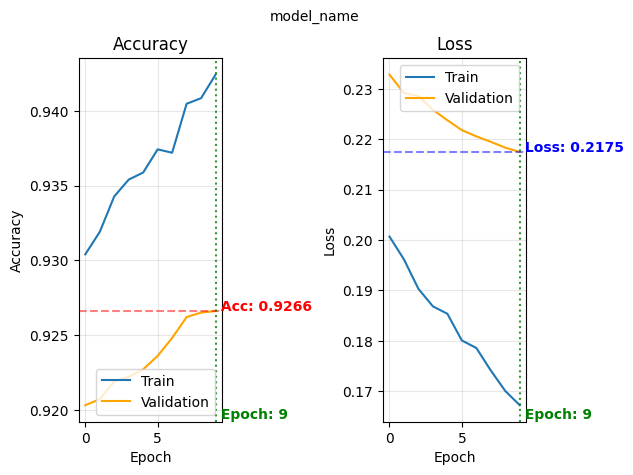

In [ ]:
acc_loss_viz(history_block6h, 'model_name')

In [ ]:
model_name="EfficientNetV2B0_block6h_Tuning_longer"
callbacks = create_callbacks(
    model_name=model_name,
    project_path=project_path,
    min_lr=1e-5,
    patience=10,
    patience_lr=3,
    factor=0.5
)

history_block6h_longer = model_block6h.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    initial_epoch=20,
    callbacks=callbacks
)

Epoch 21/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9437 - loss: 0.1644 - val_accuracy: 0.9264 - val_loss: 0.2163 - learning_rate: 1.0000e-05
Epoch 22/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9445 - loss: 0.1626 - val_accuracy: 0.9266 - val_loss: 0.2158 - learning_rate: 1.0000e-05
Epoch 23/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9441 - loss: 0.1602 - val_accuracy: 0.9277 - val_loss: 0.2139 - learning_rate: 1.0000e-05
Epoch 24/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9463 - loss: 0.1574 - val_accuracy: 0.9271 - val_loss: 0.2144 - learning_rate: 1.0000e-05
Epoch 25/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9467 - loss: 0.1527 - val_accuracy: 0.9283 - val_loss: 0.2128 - learning_rate: 1.0000e-05
Epoch 26/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9501 - loss: 0.1479 - val_accuracy: 0.9289 - val_loss: 0.2120 - learning_rate: 1.0000e-05
Epoch 27/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 1

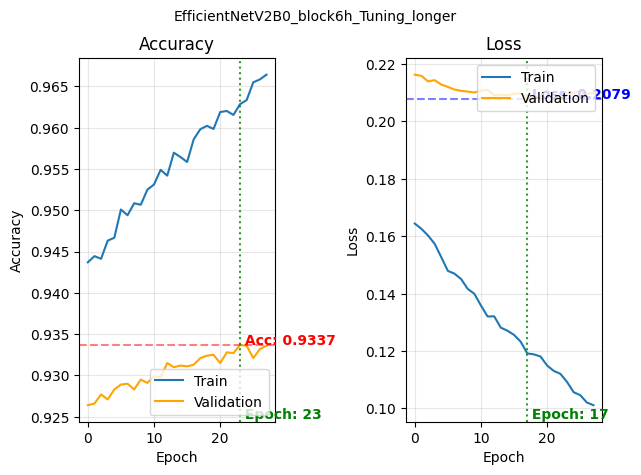

In [ ]:
acc_loss_viz(history_block6h_longer, model_name)

In [ ]:
block6h_results, y_pred, y_true = evaluate_model(
    model_name,
    model=model_block6h,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# model_block6h.save(f'{project_path}/models/N_{model_name}.keras') handled by the checkpoint function inside the create_callbacks
metrics_TL = pd.concat([metrics_TL, block6h_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880


## Test 5: Fine tuning with dropout

In [ ]:
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model_name_head = "EfficientNetV2B0_GAP_Dropout02"
model_name_ft = "EfficientNetV2B0_GAP_Dropout02_block6h"

inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) #TEST 1: Global Average Pooling
x = Dropout(0.2)(x)             #TEST 2: Dropout
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V2 = Model(inputs, outputs)

model_tuning_V2.summary()

lr = 1e-3
epochs = 10
model_tuning_V2.compile(
    optimizer=Adam(learning_rate=lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V2 = model_tuning_V2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

tuning_V2_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V2,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V2.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V2_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)



base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith("block6h") or layer.name.startswith("top_"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers[-20:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6h_V2 = model_tuning_V2  # continue from the already-trained GAP + Dropout model

model_block6h_V2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=3,
    factor=0.5
)

history_block6h_V2 = model_block6h_V2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    initial_epoch=10, #start where model_tuning_V2 stopped
    callbacks=callbacks
)

block6h_V2_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6h_V2,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# model_block6h_V2.save(f'{project_path}/models/N_{model_name_ft}.keras') handled by the checkpoint function inside the create_callbacks
metrics_TL = pd.concat([metrics_TL, block6h_V2_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)




Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_4 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - accuracy: 0.8379 - loss: 0.5145 - val_accuracy: 0.8979 - val_loss: 0.3095
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8873 - loss: 0.3335 - val_accuracy: 0.9088 - val_loss: 0.2752
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8948 - loss: 0.3099 - val_accuracy: 0.9106 - val_loss: 0.2652
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8986 - loss: 0.2940 - val_accuracy: 0.9134 - val_loss: 0.2558
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9028 - loss: 0.2800 - val_accuracy: 0.9148 - val_loss: 0.2514
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9038 - loss: 0.2774 - val_accuracy: 0.9172 - val_loss: 0.2492
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9050 - loss: 0.2737 - val_accuracy: 0.9143 - val_loss: 0.2490
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9085 - loss: 0.2629 - v

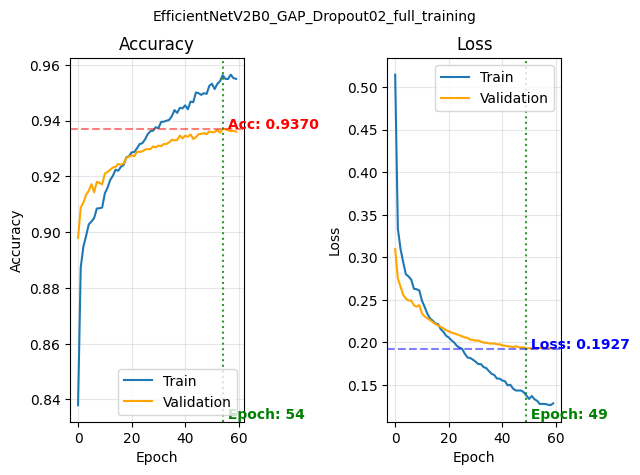

In [ ]:
combined_history = combine_histories(
    history_tuning_V2,
    history_block6h_V2
)

acc_loss_viz(
    combined_history,
    "EfficientNetV2B0_GAP_Dropout02_full_training"
)

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948


In [ ]:
for layer in base_model.layers:
    if layer.name.startswith("block6h") or layer.name.startswith("block6g") or layer.name.startswith("block6f") or layer.name.startswith("top_"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers[-60:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)


0 block6e_dwconv2 DepthwiseConv2D False
1 block6e_bn BatchNormalization False
2 block6e_activation Activation False
3 block6e_se_squeeze GlobalAveragePooling2D False
4 block6e_se_reshape Reshape False
5 block6e_se_reduce Conv2D False
6 block6e_se_expand Conv2D False
7 block6e_se_excite Multiply False
8 block6e_project_conv Conv2D False
9 block6e_project_bn BatchNormalization False
10 block6e_drop Dropout False
11 block6e_add Add False
12 block6f_expand_conv Conv2D True
13 block6f_expand_bn BatchNormalization False
14 block6f_expand_activation Activation True
15 block6f_dwconv2 DepthwiseConv2D True
16 block6f_bn BatchNormalization False
17 block6f_activation Activation True
18 block6f_se_squeeze GlobalAveragePooling2D True
19 block6f_se_reshape Reshape True
20 block6f_se_reduce Conv2D True
21 block6f_se_expand Conv2D True
22 block6f_se_excite Multiply True
23 block6f_project_conv Conv2D True
24 block6f_project_bn BatchNormalization False
25 block6f_drop Dropout True
26 block6f_add Add T

In [ ]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 5e-6  # Fine-tuning block6f/g/h/top

EPOCHS = 10

model_name_head = "EfficientNetV2B0_block6f_H"  #name for the model head
model_name_ft = "EfficientNetV2B0_block6f_T"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V3 = Model(inputs, outputs)

model_tuning_V3.summary()

model_tuning_V3.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V3 = model_tuning_V3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V3_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V3,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V3.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V3_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)


# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith("block6h") or layer.name.startswith("block6g") or layer.name.startswith("block6f") or layer.name.startswith("top_"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers[-60:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6f_V3 = model_tuning_V3  # continue from the already-trained GAP + Dropout model

model_block6f_V3.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6f_V3 = model_block6f_V3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=10, #start where model_tuning_V3 stopped
    callbacks=callbacks
)

block6f_V3_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6f_V3,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

metrics_TL = pd.concat([metrics_TL, block6f_V3_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_5 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.7406 - loss: 0.7767 - val_accuracy: 0.8899 - val_loss: 0.3420
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8014 - loss: 0.5801 - val_accuracy: 0.8969 - val_loss: 0.3130
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8121 - loss: 0.5459 - val_accuracy: 0.9008 - val_loss: 0.2955
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8163 - loss: 0.5272 - val_accuracy: 0.9009 - val_loss: 0.2961
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8211 - loss: 0.5181 - val_accuracy: 0.9012 - val_loss: 0.2870
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8249 - loss: 0.5062 - val_accuracy: 0.9063 - val_loss: 0.2763
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8265 - loss: 0.4990 - val_accuracy: 0.9051 - val_loss: 0.2773
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8291 - loss: 0.4932 - 

In [ ]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-5  # Fine-tuning block6f/g/h/top

EPOCHS = 10

model_name_head = "EfficientNetV2B0_block6f_H_LR1E05"  #name for the model head
model_name_ft = "EfficientNetV2B0_block6f_TLR1E05"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V3 = Model(inputs, outputs)

model_tuning_V3.summary()

model_tuning_V3.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V3 = model_tuning_V3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V3_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V3,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V3.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V3_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)


# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith("block6h") or layer.name.startswith("block6g") or layer.name.startswith("block6f") or layer.name.startswith("top_"):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers[-60:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6f_V3 = model_tuning_V3  # continue from the already-trained GAP + Dropout model

model_block6f_V3.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6f_V3 = model_block6f_V3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=10, #start where model_tuning_V3 stopped
    callbacks=callbacks
)

block6f_V3_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6f_V3,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

metrics_TL = pd.concat([metrics_TL, block6f_V3_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_6 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.7423 - loss: 0.7800 - val_accuracy: 0.8883 - val_loss: 0.3427
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8012 - loss: 0.5792 - val_accuracy: 0.8988 - val_loss: 0.3054
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8112 - loss: 0.5435 - val_accuracy: 0.9013 - val_loss: 0.2925
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8180 - loss: 0.5282 - val_accuracy: 0.8990 - val_loss: 0.2975
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8193 - loss: 0.5188 - val_accuracy: 0.9032 - val_loss: 0.2889
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8229 - loss: 0.5098 - val_accuracy: 0.9049 - val_loss: 0.2817
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8263 - loss: 0.5031 - val_accuracy: 0.9070 - val_loss: 0.2772
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8298 - loss: 0.4922 - 

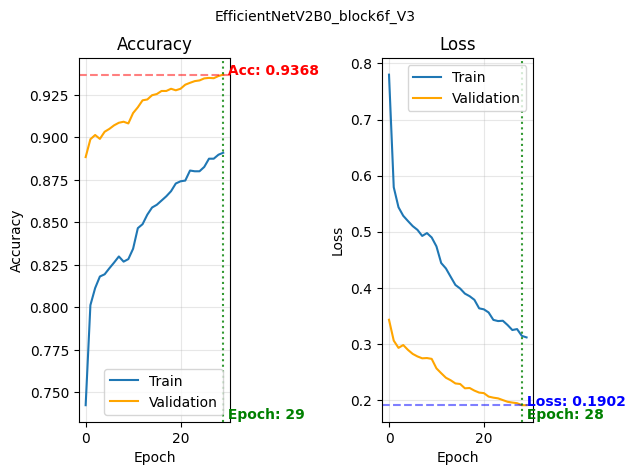

In [ ]:
combined_history = combine_histories(
    history_tuning_V3,
    history_block6f_V3
)

acc_loss_viz(
    combined_history,
    "EfficientNetV2B0_block6f_V3"
)

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


In [ ]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-5  # Fine-tuning block6f/g/h/top

EPOCHS = 10

trainable_prefixes = ("block6d", "block6e", "block6f", "block6g", "block6h", "top_")

model_name_head = "EfficientNetV2B0_block6d"  #name for the model head
model_name_ft = "EfficientNetV2B0_block6d_FT"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V4 = Model(inputs, outputs)

model_tuning_V4.summary()

model_tuning_V4.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V4 = model_tuning_V4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V4_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V4,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V4.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V4_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)


# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

for i, layer in enumerate(base_model.layers[-90:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6d_V4 = model_tuning_V4  # continue from the already-trained GAP + Dropout model

model_block6d_V4.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6d_V4 = model_block6d_V4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=10, #start where model_tuning_V4 stopped
    callbacks=callbacks
)

block6d_V4_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6d_V4,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

metrics_TL = pd.concat([metrics_TL, block6d_V4_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_7 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.7398 - loss: 0.7808 - val_accuracy: 0.8851 - val_loss: 0.3495
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8012 - loss: 0.5778 - val_accuracy: 0.8996 - val_loss: 0.3035
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8110 - loss: 0.5484 - val_accuracy: 0.8981 - val_loss: 0.3036
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8188 - loss: 0.5253 - val_accuracy: 0.9026 - val_loss: 0.2931
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8231 - loss: 0.5165 - val_accuracy: 0.9034 - val_loss: 0.2819
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8243 - loss: 0.5140 - val_accuracy: 0.9025 - val_loss: 0.2810
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8247 - loss: 0.5003 - val_accuracy: 0.9027 - val_loss: 0.2844
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8284 - loss: 0.4953 - 

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


In [ ]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 7e-6  # Fine-tuning block6f/g/h/top

EPOCHS = 5
EPOCHS_FT = 25

trainable_prefixes = ("block6a", "block6b", "block6c", "block6d", "block6e", "block6f", "block6g", "block6h", "top_")

model_name_head = "EfficientNetV2B0_block6a"  #name for the model head
model_name_ft = "EfficientNetV2B0_block6a_FT"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V5.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)


# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

for i, layer in enumerate(base_model.layers[-90:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_9 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.7411 - loss: 0.7795 - val_accuracy: 0.8859 - val_loss: 0.3501
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8004 - loss: 0.5796 - val_accuracy: 0.8944 - val_loss: 0.3111
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8137 - loss: 0.5416 - val_accuracy: 0.8985 - val_loss: 0.3008
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8169 - loss: 0.5250 - val_accuracy: 0.8992 - val_loss: 0.2908
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8216 - loss: 0.5151 - val_accuracy: 0.9056 - val_loss: 0.2851
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step
0 block6c_dwconv2 DepthwiseConv2D True
1 block6c_bn BatchNormalization False
2 block6c_activation Activation True
3 block6c_se_squeeze GlobalAveragePooling2D True
4 block6c_se_reshape Reshape True
5 block6c_se_reduce Conv2D True
6 block6c_se_expand Conv2D True
7 block6c_se_excite Multiply True
8 block6c_project_

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


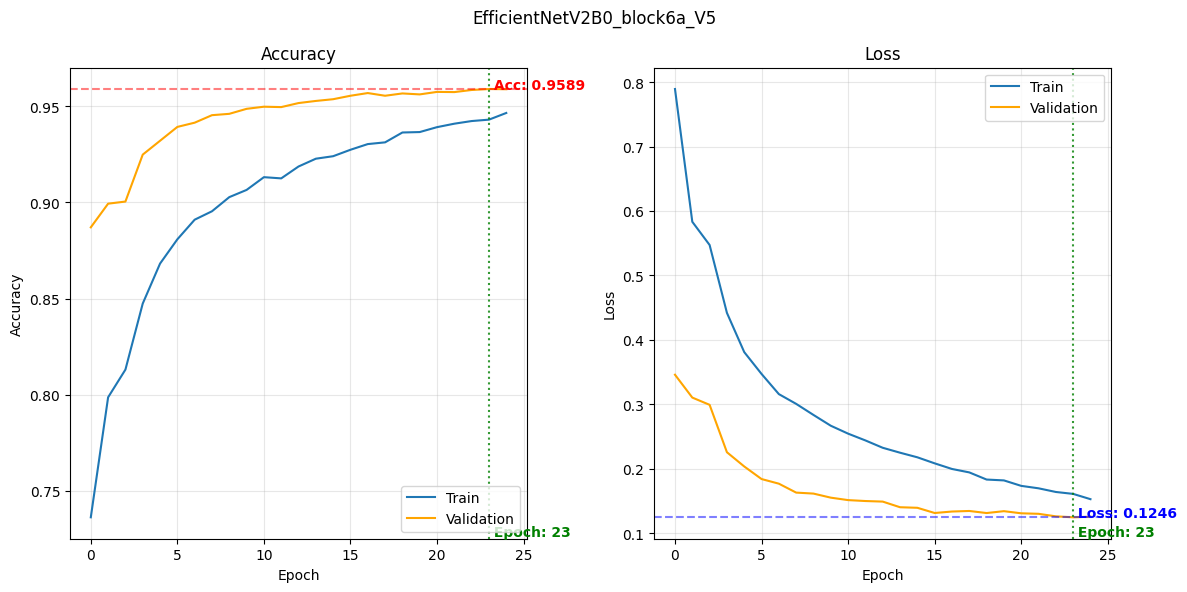

In [ ]:
combined_history = combine_histories(
    history_tuning_V5,
    history_block6a_V5
)

acc_loss_viz(
    combined_history,
    "EfficientNetV2B0_block6a_V5"
)

##Test 6: Deeper tuning

In [ ]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-5  # Fine-tuning block6a/b/c/d/ef/g/h/top

EPOCHS = 3
EPOCHS_FT = 25

trainable_prefixes = ("block6a", "block6b", "block6c", "block6d", "block6e", "block6f", "block6g", "block6h", "top_")

model_name_head = "EfficientNetV2B0_block6a_V2"  #name for the model head
model_name_ft = "EfficientNetV2B0_block6a_FT_V2"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V5.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)


# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

for i, layer in enumerate(base_model.layers[-90:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_10 (Resizing)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.7363 - loss: 0.7893 - val_accuracy: 0.8870 - val_loss: 0.3458
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7987 - loss: 0.5832 - val_accuracy: 0.8993 - val_loss: 0.3104
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8130 - loss: 0.5472 - val_accuracy: 0.9004 - val_loss: 0.2991
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step
0 block6c_dwconv2 DepthwiseConv2D True
1 block6c_bn BatchNormalization False
2 block6c_activation Activation True
3 block6c_se_squeeze GlobalAveragePooling2D True
4 block6c_se_reshape Reshape True
5 block6c_se_reduce Conv2D True
6 block6c_se_expand Conv2D True
7 block6c_se_excite Multiply True
8 block6c_project_conv Conv2D True
9 block6c_project_bn BatchNormalization False
10 block6c_drop Dropout True
11 block6c_add Add True
12 block6d_expand_conv Conv2D True
13 block6d_expand_bn BatchNormalization False
14 block6d_expand_activation Activation True
15 block6d_dwcon

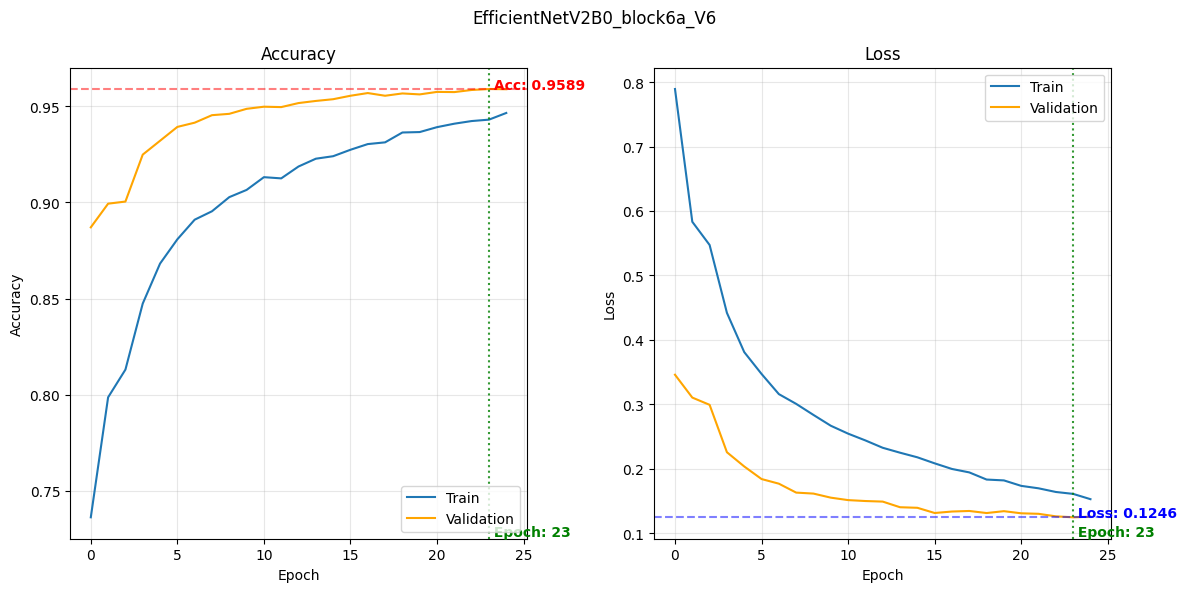

In [ ]:
combined_history = combine_histories(
    history_tuning_V5,
    history_block6a_V5
)

acc_loss_viz(
    combined_history,
    "EfficientNetV2B0_block6a_V6"
)

In [ ]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


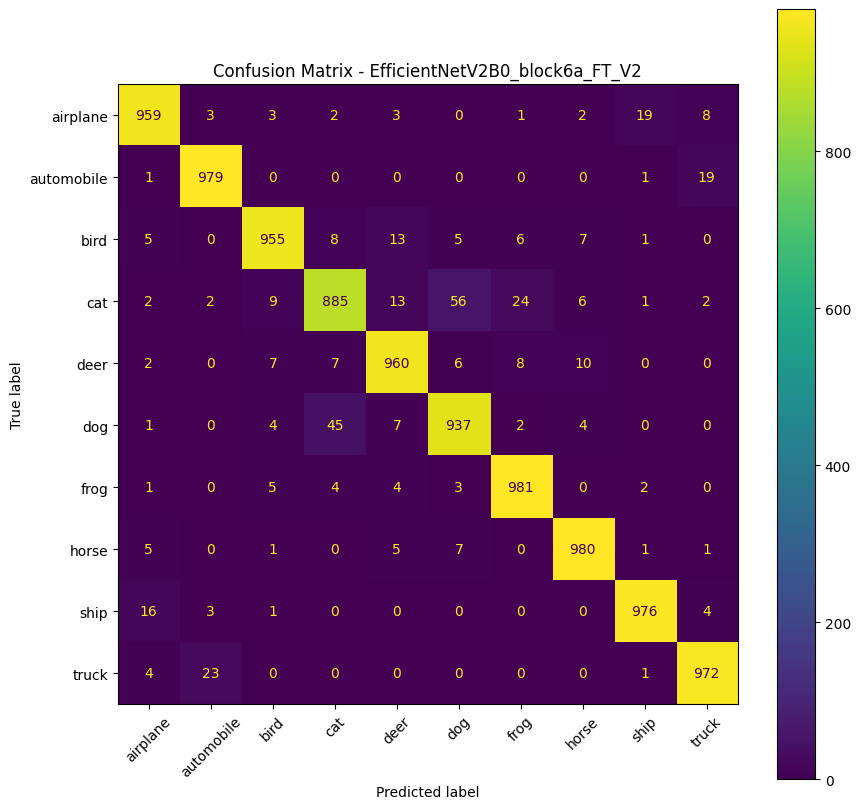

In [ ]:
cm_gap = confuse(y_true, y_pred, title=f"Confusion Matrix - {model_name_ft}")

## Test 7 : improve augmentation

In [ ]:

# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-5  # Fine-tuning block6f/g/h/top

EPOCHS = 1
EPOCHS_FT = 20

trainable_prefixes = ("block6a", "block6b", "block6c", "block6d", "block6e", "block6f", "block6g", "block6h", "top_")

model_name_head = "EfficientNetV2B0_block6a_V3"  #name for the model head
model_name_ft = "EfficientNetV2B0_block6a_FT_V3"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.08),
    RandomZoom(0.1),
    RandomTranslation(0.08, 0.08),
    RandomContrast(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

model_tuning_V5.save(f'{project_path}/models/N_{model_name_head}.keras')
metrics_TL = pd.concat([metrics_TL, tuning_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)


# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )



model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_11 (Resizing)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.6637 - loss: 0.9906 - val_accuracy: 0.8699 - val_loss: 0.4041
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step
0 block6c_dwconv2 DepthwiseConv2D True
1 block6c_bn BatchNormalization False
2 block6c_activation Activation True
3 block6c_se_squeeze GlobalAveragePooling2D True
4 block6c_se_reshape Reshape True
5 block6c_se_reduce Conv2D True
6 block6c_se_expand Conv2D True
7 block6c_se_excite Multiply True
8 block6c_project_conv Conv2D True
9 block6c_project_bn BatchNormalization False
10 block6c_drop Dropout True
11 block6c_add Add True
12 block6d_expand_conv Conv2D True
13 block6d_expand_bn BatchNormalization False
14 block6d_expand_activation Activation True
15 block6d_dwconv2 DepthwiseConv2D True
16 block6d_bn BatchNormalization False
17 block6d_activation Activation True
18 block6d_se_squeeze GlobalAveragePooling2D True
19 block6d_se_reshape Reshape True
20 block6d_se_reduce Conv2D True
21 block6d_se_expand Conv2D True
22 block6d_se_ex

In [ ]:
for i, layer in enumerate(base_model.layers[-200:]):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

0 block4c_se_expand Conv2D False
1 block4c_se_excite Multiply False
2 block4c_project_conv Conv2D False
3 block4c_project_bn BatchNormalization False
4 block4c_drop Dropout False
5 block4c_add Add False
6 block5a_expand_conv Conv2D False
7 block5a_expand_bn BatchNormalization False
8 block5a_expand_activation Activation False
9 block5a_dwconv2 DepthwiseConv2D False
10 block5a_bn BatchNormalization False
11 block5a_activation Activation False
12 block5a_se_squeeze GlobalAveragePooling2D False
13 block5a_se_reshape Reshape False
14 block5a_se_reduce Conv2D False
15 block5a_se_expand Conv2D False
16 block5a_se_excite Multiply False
17 block5a_project_conv Conv2D False
18 block5a_project_bn BatchNormalization False
19 block5b_expand_conv Conv2D False
20 block5b_expand_bn BatchNormalization False
21 block5b_expand_activation Activation False
22 block5b_dwconv2 DepthwiseConv2D False
23 block5b_bn BatchNormalization False
24 block5b_activation Activation False
25 block5b_se_squeeze GlobalAver

## Test 8: deep tuning v2

In [22]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 5e-6  # Fine-tuning block6a/b/c/d/ef/g/h/top

EPOCHS = 1
EPOCHS_FT = 20

trainable_prefixes = ("block6", 'block5', "top_")

model_name_head = "EfficientNetV2B0_block5_H"  #name for the model head
model_name_ft = "EfficientNetV2B0_block5_FT"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

#model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

trainable_layers = sum(layer.trainable for layer in base_model.layers)
total_layers = len(base_model.layers)

print(f"Trainable layers: {trainable_layers}/{total_layers}")
print(f"Ratio: {trainable_layers / total_layers:.2%}")

model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)
metrics_TL = pd.read_csv(f"{project_path}/metrics/N_TL_metrics_.csv")
metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.7406 - loss: 0.7793 - val_accuracy: 0.8911 - val_loss: 0.3368
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step
Trainable layers: 154/270
Ratio: 57.04%
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 67ms/step - accuracy: 0.8478 - loss: 0.4394 - val_accuracy: 0.9295 - val_loss: 0.2141 - learning_rate: 5.0000e-06
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8825 - loss: 0.3483 - val_accuracy: 0.9384 - val_loss: 0.1862 - learning_rate: 5.0000e-06
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8939 - loss: 0.3066 - val_accuracy: 0.9437 - val_loss: 0.1645 - learning_rate: 5.0000e-06
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9034 - loss: 0.2818 - val_accuracy: 0.9472 - val_loss: 0.1561 - learning_rate: 5.0000e-06
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9100 - loss: 0.2605 - val_accuracy: 0.9503 - val_loss: 0.1458 - learning_rate: 5.0000e-06
Epoch 7/2

In [23]:
metrics_TL


,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


## Test 9: deep tuning V3

In [34]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 5e-6  # Fine-tuning block6a/b/c/d/ef/g/h/top

EPOCHS = 1
EPOCHS_FT = 20

trainable_prefixes = ("block6", 'block5' ,'block4' , 'block3', "top_")

model_name_head = "EfficientNetV2B0_block3_H"  #name for the model head
model_name_ft = "EfficientNetV2B0_block3_FT"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

#model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

trainable_layers = sum(layer.trainable for layer in base_model.layers)
total_layers = len(base_model.layers)

print(f"Trainable layers: {trainable_layers}/{total_layers}")
print(f"Ratio: {trainable_layers / total_layers:.2%}")

model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)
metrics_TL = pd.read_csv(f"{project_path}/metrics/N_TL_metrics_.csv")
metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.7334 - loss: 0.7948 - val_accuracy: 0.8828 - val_loss: 0.3529
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step
Trainable layers: 196/270
Ratio: 72.59%
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 72ms/step - accuracy: 0.8569 - loss: 0.4128 - val_accuracy: 0.9321 - val_loss: 0.2083 - learning_rate: 5.0000e-06
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8894 - loss: 0.3224 - val_accuracy: 0.9397 - val_loss: 0.1774 - learning_rate: 5.0000e-06
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9019 - loss: 0.2852 - val_accuracy: 0.9461 - val_loss: 0.1563 - learning_rate: 5.0000e-06
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9114 - loss: 0.2580 - val_accuracy: 0.9500 - val_loss: 0.1453 - learning_rate: 5.0000e-06
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9180 - loss: 0.2444 - val_accuracy: 0.9500 - val_loss: 0.1417 - learning_rate: 5.0000e-06
Epoch 7/2

In [35]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


## Test 10: Deep tuning V4

In [37]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-5  # Fine-tuning block6a/b/c/d/ef/g/h/top

EPOCHS = 1
EPOCHS_FT = 20

trainable_prefixes = ("block6", 'block5' ,'block4' , 'block3', 'block2','block1',"top_")

model_name_head = "EfficientNetV2B0_TOTAL_H"  #name for the model head
model_name_ft = "EfficientNetV2B0_TOTAL_FT"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

#model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

trainable_layers = sum(layer.trainable for layer in base_model.layers)
total_layers = len(base_model.layers)

print(f"Trainable layers: {trainable_layers}/{total_layers}")
print(f"Ratio: {trainable_layers / total_layers:.2%}")

model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=1e-6,
    patience=10,
    patience_lr=10,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)
metrics_TL = pd.read_csv(f"{project_path}/metrics/N_TL_metrics_.csv")
metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.7390 - loss: 0.7850 - val_accuracy: 0.8875 - val_loss: 0.3454
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step
Trainable layers: 206/270
Ratio: 76.30%
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 79ms/step - accuracy: 0.8729 - loss: 0.3701 - val_accuracy: 0.9425 - val_loss: 0.1692 - learning_rate: 1.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9064 - loss: 0.2723 - val_accuracy: 0.9518 - val_loss: 0.1470 - learning_rate: 1.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9179 - loss: 0.2385 - val_accuracy: 0.9564 - val_loss: 0.1335 - learning_rate: 1.0000e-05
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9273 - loss: 0.2124 - val_accuracy: 0.9601 - val_loss: 0.1218 - learning_rate: 1.0000e-05
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9340 - loss: 0.1897 - val_accuracy: 0.9629 - val_loss: 0.1109 - learning_rate: 1.0000e-05
Epoch 7/2

In [38]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


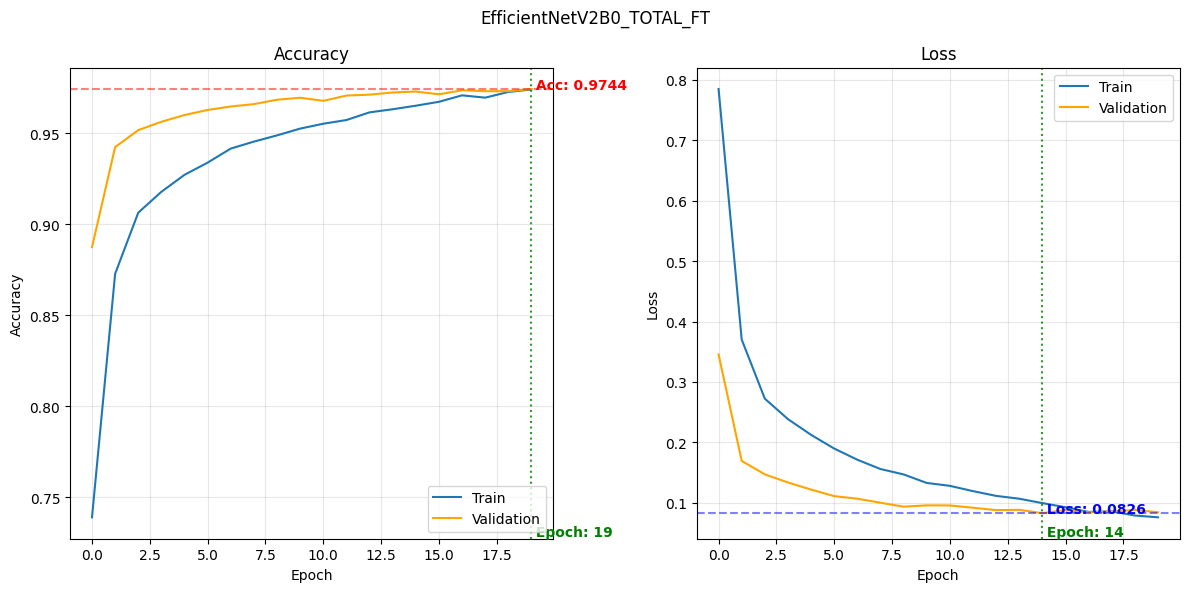

In [39]:
combined_history = combine_histories(
    history_tuning_V5,
    history_block6a_V5
)

acc_loss_viz(
    combined_history,
    model_name_ft
)

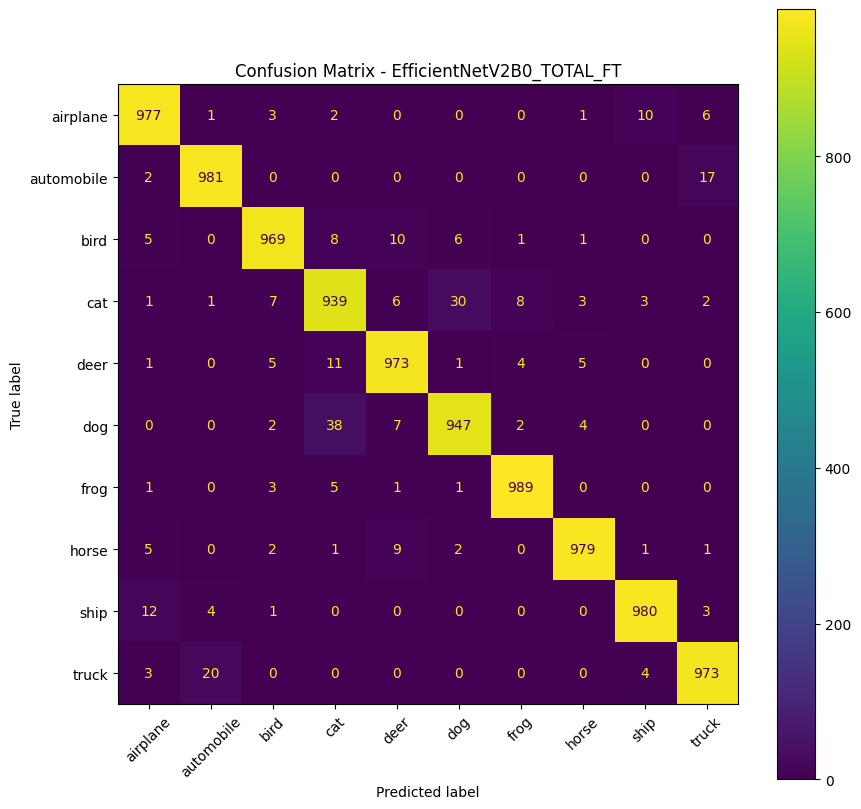

In [40]:
cm_gap = confuse(y_true, y_pred, title=f"Confusion Matrix - {model_name_ft}")

## Test 11: Deep tuning final version

In [41]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-4  # Fine-tuning block6a/b/c/d/ef/g/h/top

EPOCHS = 1
EPOCHS_FT = 20

trainable_prefixes = ("block6", 'block5' ,'block4' , 'block3', 'block2','block1',"top_")

model_name_head = "EfficientNetV2B0_TOTAL_H_V2"  #name for the model head
model_name_ft = "EfficientNetV2B0_TOTAL_FT_V2"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")


inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

#model_tuning_V5.summary()

model_tuning_V5.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tuning_V5 = model_tuning_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

tuning_V5_results, y_pred, y_true = evaluate_model(
    model_name_head,
    model=model_tuning_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)

# --------------- | FINE TUNING | -------------------------------------------


base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

trainable_layers = sum(layer.trainable for layer in base_model.layers)
total_layers = len(base_model.layers)

print(f"Trainable layers: {trainable_layers}/{total_layers}")
print(f"Ratio: {trainable_layers / total_layers:.2%}")

model_block6a_V5 = model_tuning_V5  # continue from the already-trained GAP + Dropout model

model_block6a_V5.compile(
    optimizer=Adam(learning_rate=LR_FINE_TUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = create_callbacks(
    model_name= model_name_ft,
    project_path=project_path,
    min_lr=5e-5,
    patience=6,
    patience_lr=3,
    factor=0.5
)

history_block6a_V5 = model_block6a_V5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    initial_epoch=EPOCHS, #start where model_tuning_V5 stopped
    callbacks=callbacks
)

block6a_V5_results, y_pred, y_true = evaluate_model(
    model_name_ft,
    model=model_block6a_V5,
    train_data=train_ds,
    test_data=test_ds,
    y_test=y_test
)
metrics_TL = pd.read_csv(f"{project_path}/metrics/N_TL_metrics_.csv")
metrics_TL = pd.concat([metrics_TL, block6a_V5_results], ignore_index=True)
metrics_TL.to_csv(f"{project_path}/metrics/N_TL_metrics_.csv", index=False)

625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.7412 - loss: 0.7809 - val_accuracy: 0.8878 - val_loss: 0.3389
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step
Trainable layers: 206/270
Ratio: 76.30%
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.8989 - loss: 0.2943 - val_accuracy: 0.9543 - val_loss: 0.1386 - learning_rate: 1.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9375 - loss: 0.1833 - val_accuracy: 0.9619 - val_loss: 0.1175 - learning_rate: 1.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9514 - loss: 0.1416 - val_accuracy: 0.9612 - val_loss: 0.1165 - learning_rate: 1.0000e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9609 - loss: 0.1148 - val_accuracy: 0.9671 - val_loss: 0.0969 - learning_rate: 1.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9681 - loss: 0.0925 - val_accuracy: 0.9679 - val_loss: 0.0917 - learning_rate: 1.0000e-04
Epoch 7/2

In [42]:
metrics_TL

,Model,Train Accuracy,Train Loss,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,EfficientNetV2B0_baseline,0.993750,0.059542,0.9103,2.537352,0.910358,0.9103,0.910024
1,EfficientNetV2B0_GAP,0.943525,0.167351,0.9143,0.244746,0.914400,0.9143,0.914126
2,EfficientNetV2B0_Dropout,0.934325,0.195196,0.9127,0.251770,0.913102,0.9127,0.912639
3,EfficientNetV2B0_E100P10ML1e-06PL3F0.5,0.943000,0.169150,0.9173,0.241772,0.917623,0.9173,0.917287
4,EfficientNetV2B0_block6h_Tuning,0.958500,0.126266,0.9242,0.221769,0.923974,0.9242,0.924015
5,EfficientNetV2B0_block6h_Tuning_longer,0.979025,0.073232,0.9279,0.211315,0.927989,0.9279,0.927880
6,EfficientNetV2B0_GAP_Dropout02,0.935800,0.189565,0.9108,0.254309,0.912103,0.9108,0.910767
7,EfficientNetV2B0_GAP_Dropout02_block6h,0.978650,0.072482,0.9320,0.197472,0.932036,0.9320,0.931948
8,EfficientNetV2B0_block6f_H,0.918500,0.244039,0.9022,0.279353,0.902390,0.9022,0.901530
9,EfficientNetV2B0_block6f_T,0.940800,0.175690,0.9228,0.220292,0.922727,0.9228,0.922341


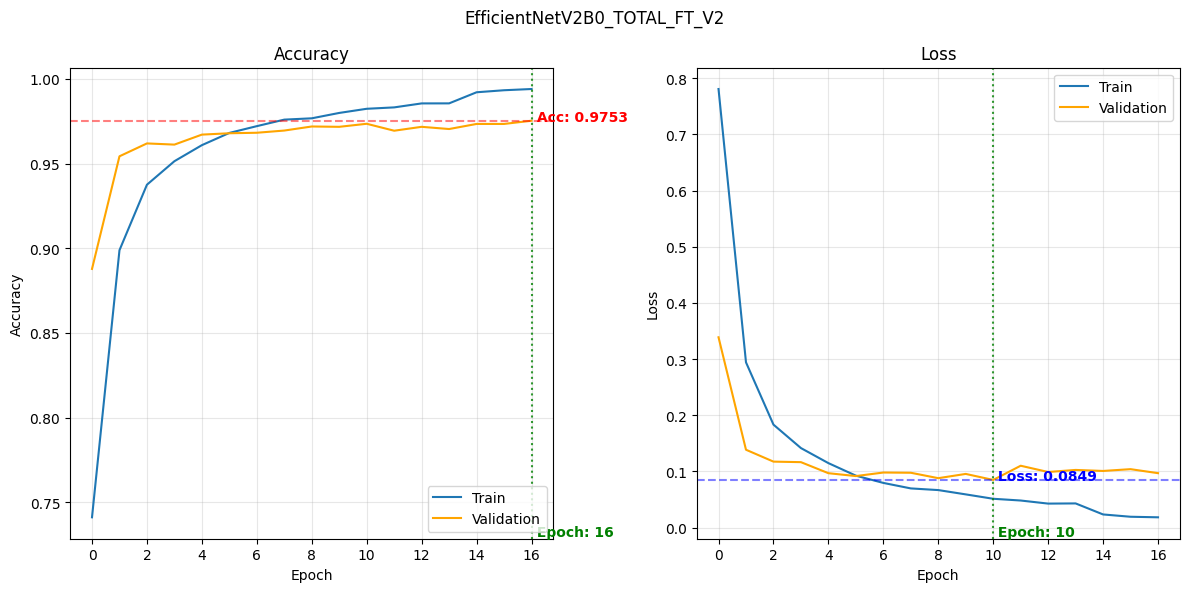

In [44]:
combined_history = combine_histories(
    history_tuning_V5,
    history_block6a_V5
)

acc_loss_viz(
    combined_history,
    model_name_ft
)

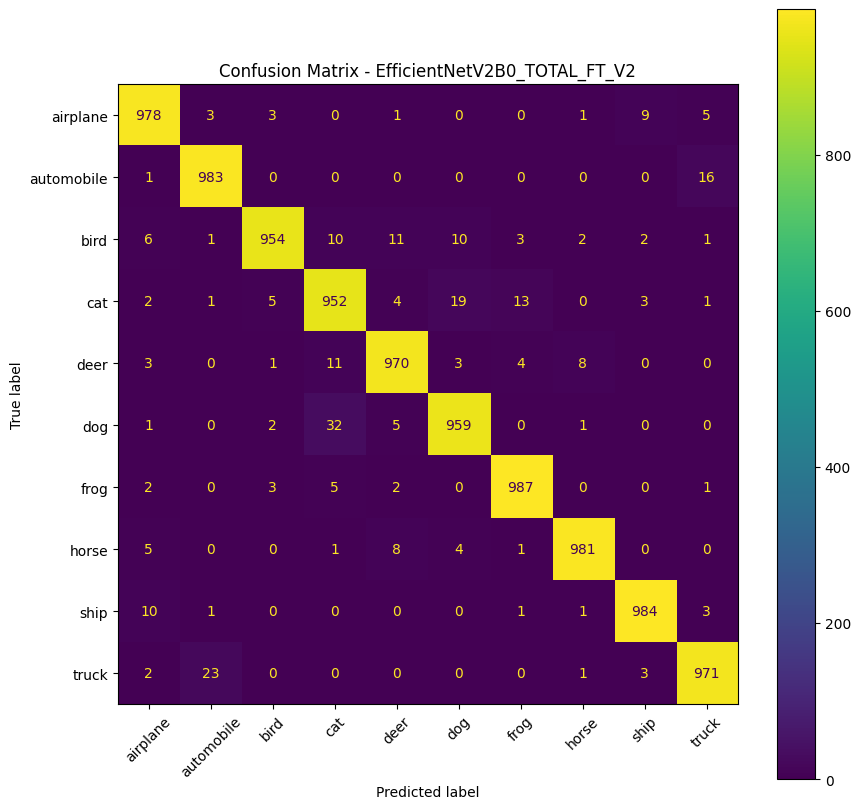

In [43]:
cm_TOTAL_V2 = confuse(y_true, y_pred, title=f"Confusion Matrix - {model_name_ft}")

## Miscellaneous

In [12]:
IMG_SIZE = 224
BATCH_SIZE = 64
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(("block6", 'block5' ,'block4' , 'block3', 'block2','block1',"top_"))
        and not isinstance(layer, BatchNormalization)
    )

trainable_layers = sum(layer.trainable for layer in base_model.layers)
total_layers = len(base_model.layers)

print(f"Trainable layers: {trainable_layers}/{total_layers}")
print(f"Ratio: {trainable_layers / total_layers:.2%}")

Trainable layers: 206/270
Ratio: 76.30%


/tmp/ipykernel_9388/892061042.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


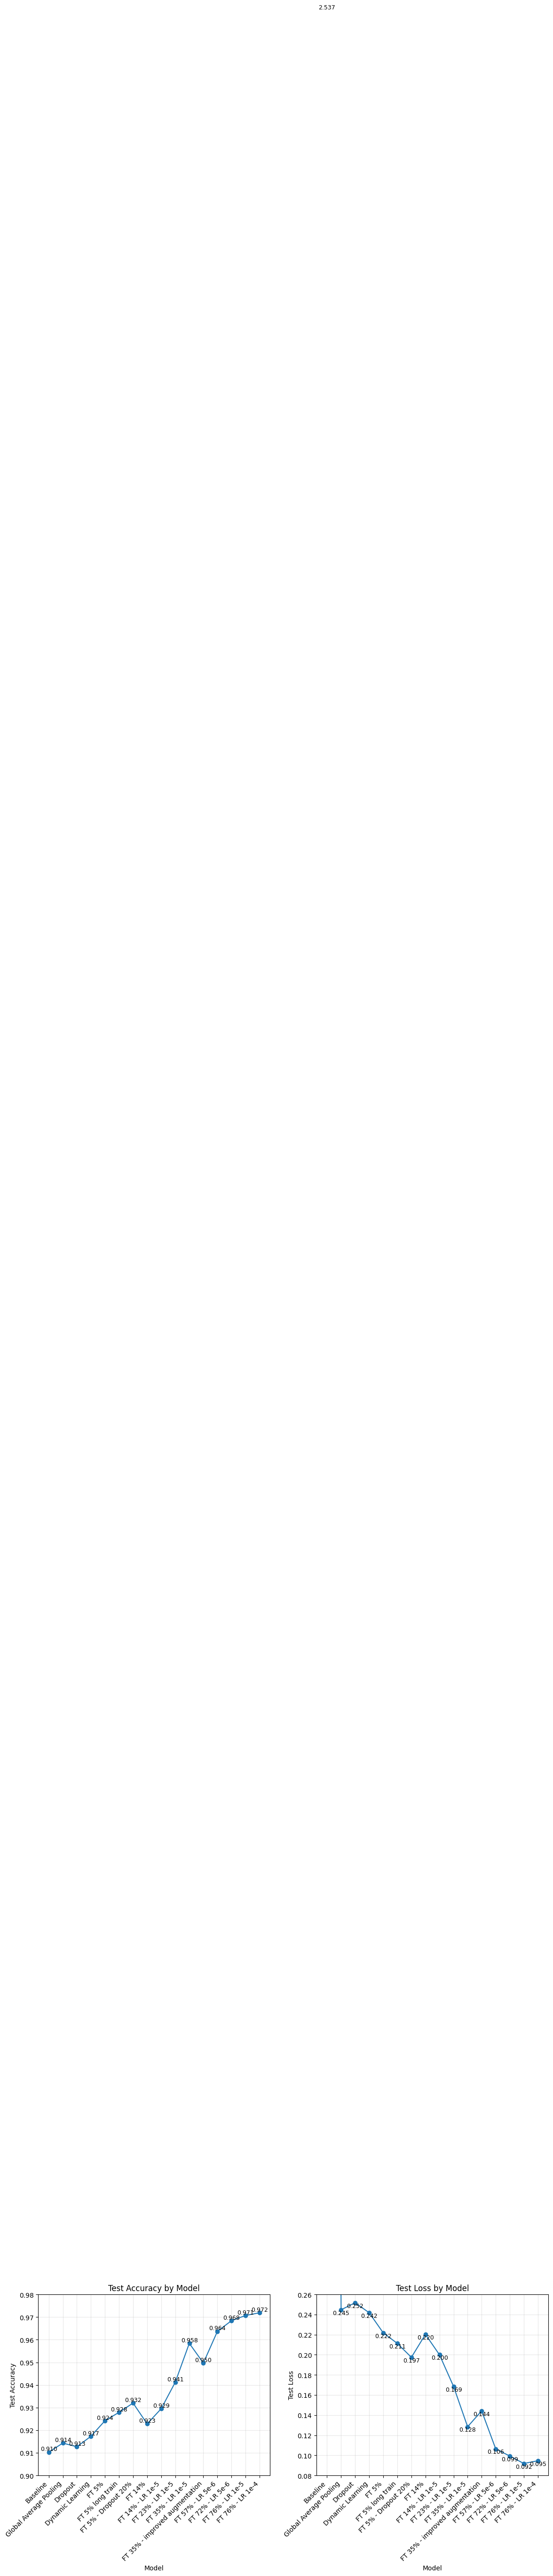

In [24]:
# Load data
df = pd.read_csv(f"{project_path}/metrics/N_TL_metrics_ (2).csv")


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

# Test Accuracy
axes[0].plot(x, df["Test Accuracy"], marker="o", label="Test Accuracy")
axes[0].set_title("Test Accuracy by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["Model"], rotation=45, ha="right")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.9, 0.98)

for i, value in enumerate(df["Test Accuracy"]):
    axes[0].text(i, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

# Test Loss
axes[1].plot(x, df["Test Loss"], marker="o", label="Test Loss")
axes[1].set_title("Test Loss by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Test Loss")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df["Model"], rotation=45, ha="right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.08, 0.26)

for i, value in enumerate(df["Test Loss"]):
    axes[1].text(i, value, f"{value:.3f}", ha="center", va="top", fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_9388/72930690.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


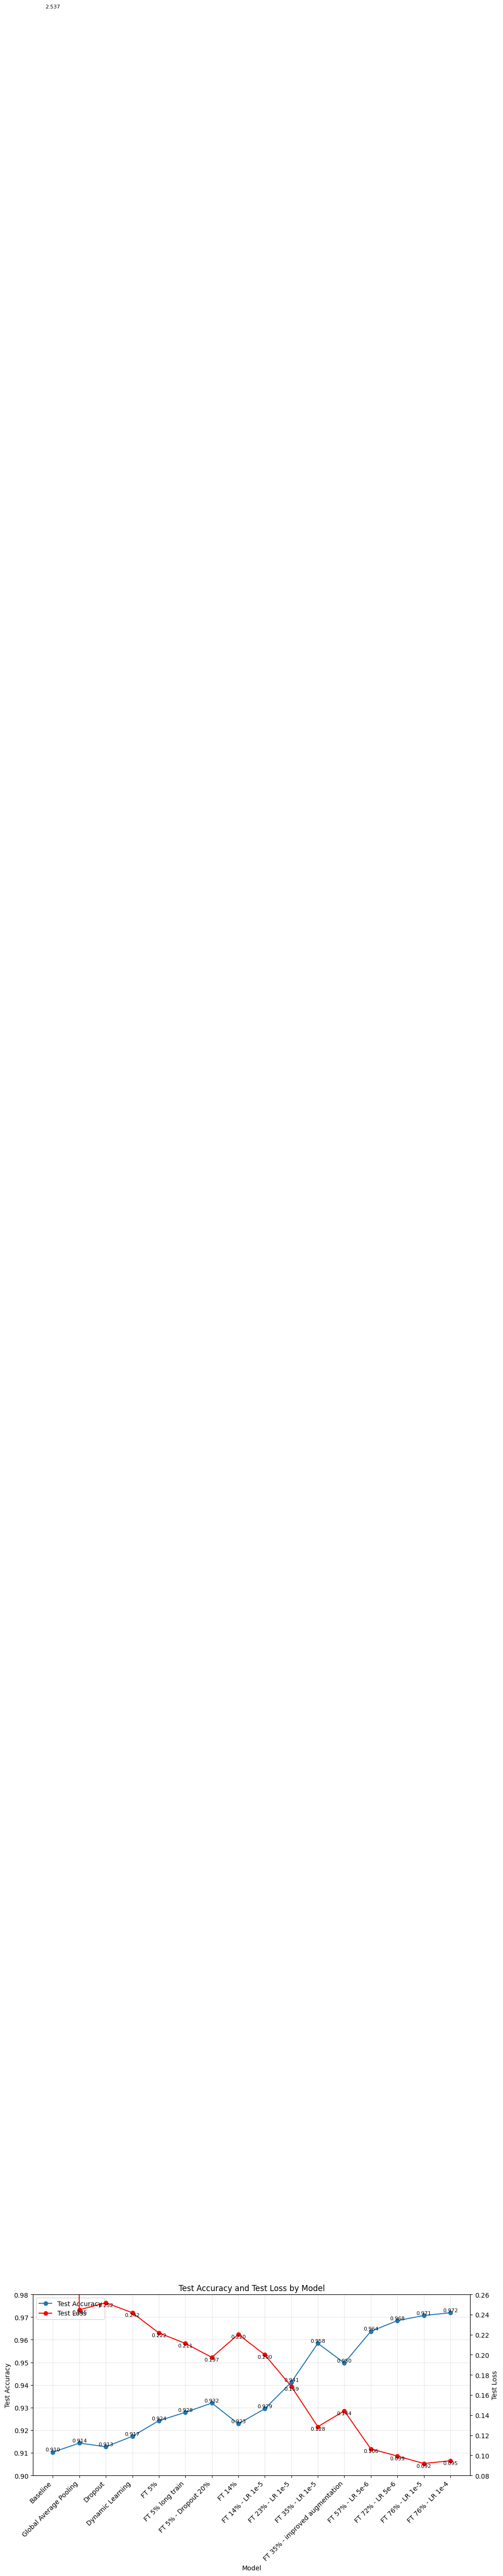

In [28]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# X positions
x = range(len(df))

# Accuracy on left y-axis
ax1.plot(x, df["Test Accuracy"], marker="o", label="Test Accuracy")
ax1.set_xlabel("Model")
ax1.set_ylabel("Test Accuracy")
ax1.set_ylim(0.90, 0.98)
ax1.set_xticks(x)
ax1.set_xticklabels(df["Model"], rotation=45, ha="right")
ax1.grid(True, alpha=0.3)

# Loss on right y-axis
ax2 = ax1.twinx()
ax2.plot(x, df["Test Loss"], marker="o", label="Test Loss", color="red")
ax2.set_ylabel("Test Loss")
ax2.set_ylim(0.08, 0.26)

# Value labels
for i, row in df.iterrows():
    ax1.text(i, row["Test Accuracy"], f'{row["Test Accuracy"]:.3f}',
             ha="center", va="bottom", fontsize=8)

    ax2.text(i, row["Test Loss"], f'{row["Test Loss"]:.3f}',
             ha="center", va="top", fontsize=8)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Test Accuracy and Test Loss by Model")
plt.tight_layout()
plt.show()

In [5]:
# --------------- | VARIABLES | ------------------------------------------
LR_HEAD = 1e-3 # Frozen head training
LR_FINE_TUNE = 1e-4  # Fine-tuning block6a/b/c/d/ef/g/h/top

EPOCHS = 1
EPOCHS_FT = 20

trainable_prefixes = ("block6", 'block5' ,'block4' , 'block3', 'block2','block1',"top_")

model_name_head = "EfficientNetV2B0_TOTAL_H_V2"  #name for the model head
model_name_ft = "EfficientNetV2B0_TOTAL_FT_V2"    #name for fine tuned model

# --------------- | HEAD TRAINING | ---------------------------------------
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.1),
], name="data_augmentation")

base_model.trainable = True


for layer in base_model.layers:
    layer.trainable = (
        layer.name.startswith(trainable_prefixes)
        and not isinstance(layer, BatchNormalization)
    )

inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(224, 224)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation="softmax")(x)

# Build the full model connecting inputs to outputs
model_tuning_V5 = Model(inputs, outputs)

model_tuning_V5.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 5,810,042 (22.16 MB)

 Non-trainable params: 122,080 (476.88 KB)

In [4]:
model_tuning_V5.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [6]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

0 input_layer_3 InputLayer False
1 rescaling_1 Rescaling False
2 normalization_1 Normalization False
3 stem_conv Conv2D False
4 stem_bn BatchNormalization False
5 stem_activation Activation False
6 block1a_project_conv Conv2D True
7 block1a_project_bn BatchNormalization False
8 block1a_project_activation Activation True
9 block2a_expand_conv Conv2D True
10 block2a_expand_bn BatchNormalization False
11 block2a_expand_activation Activation True
12 block2a_project_conv Conv2D True
13 block2a_project_bn BatchNormalization False
14 block2b_expand_conv Conv2D True
15 block2b_expand_bn BatchNormalization False
16 block2b_expand_activation Activation True
17 block2b_project_conv Conv2D True
18 block2b_project_bn BatchNormalization False
19 block2b_drop Dropout True
20 block2b_add Add True
21 block3a_expand_conv Conv2D True
22 block3a_expand_bn BatchNormalization False
23 block3a_expand_activation Activation True
24 block3a_project_conv Conv2D True
25 block3a_project_bn BatchNormalization False

In [12]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
project_path = '/content/drive/MyDrive/CNN_project'

model = tf.keras.models.load_model(f"{project_path}/models/N_EfficientNetV2B0_TOTAL_FT_V2.keras")

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_test  # already integer labels: 0, 1, 2, ..., 9

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

157/157 ━━━━━━━━━━━━━━━━━━━━ 710s 4s/step
              precision    recall  f1-score   support

    airplane       0.97      0.98      0.97      1000
  automobile       0.97      0.98      0.98      1000
        bird       0.99      0.95      0.97      1000
         cat       0.94      0.95      0.95      1000
        deer       0.97      0.97      0.97      1000
         dog       0.96      0.96      0.96      1000
        frog       0.98      0.99      0.98      1000
       horse       0.99      0.98      0.98      1000
        ship       0.98      0.98      0.98      1000
       truck       0.97      0.97      0.97      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

